In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd {_repo_root[0]}
del _repo_root

/Users/alex.shtoff/git/spectral_neuron_paper


# HIGGS scaling

Reader-facing companion for the dense HIGGS one-pass scaling experiment. It validates raw result completeness, performs validation-only learning-rate selection, and compares parameter-matched spectral and constant-width MLP families. It makes no empirical claim until a complete result file has been loaded and the cells have run.

## Setup

In [2]:
import warnings

import matplotlib as mpl
import numpy as np
import pandas as pd

from paper.experiments.higgs_scaling import (
    PROFILES,
    default_raw_path,
    select_lr,
    summarize_raw,
    validate_raw,
)
from paper.plotting import plot_higgs_models_by_dimension

mpl.rcParams["figure.dpi"] = 140

In [3]:
profile_name = "full"
variant = None  # Or one model name to inspect a single-family shard.
profile = PROFILES[profile_name]
raw_path = default_raw_path(profile_name, variant)
metric = "logloss"  # Or "brier".

## Context and assumptions

- Rows 0–9,999,999 train the models, the next 500,000 form validation, and the official final 500,000 rows form test. File order is not time.
- Means and standard deviations are fitted once on the complete training partition and then fixed for every checkpoint and model.
- A trajectory consumes nested prefixes of one shuffled order. The x-axis is examples seen by the optimizer, not independently fitted dataset size.
- Validation log loss at the final checkpoint selects one learning rate per model family and capacity. Evaluation retrains once with that rate and reports all checkpoints from the same trajectory.
- Lines are medians across paired data-order and initialization seeds; bands are interquartile seed variation on one fixed test partition, not confidence intervals for a test population.

## Load and validate results

In [4]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"{raw_path} does not exist; run paper.experiments.higgs_scaling first"
    )

raw = pd.read_csv(raw_path)
validate_raw(raw, profile, variant)

## Validation selection and recorded capacity

In [5]:
selected = select_lr(raw)
selected_lrs = selected[["model", "dim", "selected_lr"]].drop_duplicates()
boundaries = selected_lrs.loc[
    np.isclose(selected_lrs["selected_lr"], min(profile.lrs))
    | np.isclose(selected_lrs["selected_lr"], max(profile.lrs))
]
if not boundaries.empty:
    warnings.warn(
        "selected learning rate touches the tuning-grid boundary for:\n"
        + boundaries.to_string(index=False),
        stacklevel=1,
    )

capacity_table = (
    selected[["model", "dim", "width", "num_parameters"]]
    .drop_duplicates()
    .sort_values(["dim", "model"], kind="stable")
    .reset_index(drop=True)
)
capacity_table

,model,dim,width,num_parameters
0,linear,0,0,29
1,mlp-1,3,6,181
2,mlp-2,3,5,181
3,mlp-3,3,4,161
4,spectral,3,0,174
5,mlp-1,5,14,421
6,mlp-2,5,10,411
7,mlp-3,5,9,451
8,spectral,5,0,435
9,mlp-1,9,43,1291


## Selected test summary

In [6]:
summary = summarize_raw(raw)
summary[[
    "train_size", "model", "dim", "width", "num_parameters",
    "selected_lr", "median_test_logloss", "q25_test_logloss",
    "q75_test_logloss", "median_test_brier", "q25_test_brier",
    "q75_test_brier", "n",
]].sort_values(["train_size", "dim", "model"], kind="stable")

,train_size,model,dim,width,num_parameters,selected_lr,median_test_logloss,q25_test_logloss,q75_test_logloss,median_test_brier,q25_test_brier,q75_test_brier,n
0,4096,linear,0,0,29,0.001585,0.727148,0.720838,0.742198,0.265486,0.261691,0.271740,6
8,4096,mlp-1,3,6,181,0.025119,0.696438,0.690639,0.697717,0.251630,0.248747,0.252197,6
40,4096,mlp-2,3,5,181,0.006310,0.697508,0.694315,0.705831,0.252120,0.250562,0.256287,6
72,4096,mlp-3,3,4,161,0.006310,0.710728,0.699400,0.714424,0.258718,0.253108,0.260526,6
104,4096,spectral,3,0,174,0.006310,0.712220,0.697029,0.717041,0.258783,0.251628,0.261016,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,10000000,spectral,9,0,1305,0.006310,0.535010,0.534742,0.535505,0.180048,0.179847,0.180297,6
39,10000000,mlp-1,15,116,3481,0.006310,0.516747,0.516212,0.517853,0.172729,0.172593,0.173185,6
71,10000000,mlp-2,15,45,3421,0.006310,0.502692,0.502395,0.503104,0.167654,0.167515,0.167796,6
103,10000000,mlp-3,15,34,3401,0.006310,0.504732,0.504673,0.504931,0.168455,0.168429,0.168519,6


## Scaling curves

The matched-family plot requires the merged result rather than an individual variant shard. Facet annotations are read from `width` and `num_parameters` in the selected rows; they are not reconstructed from a lookup table.

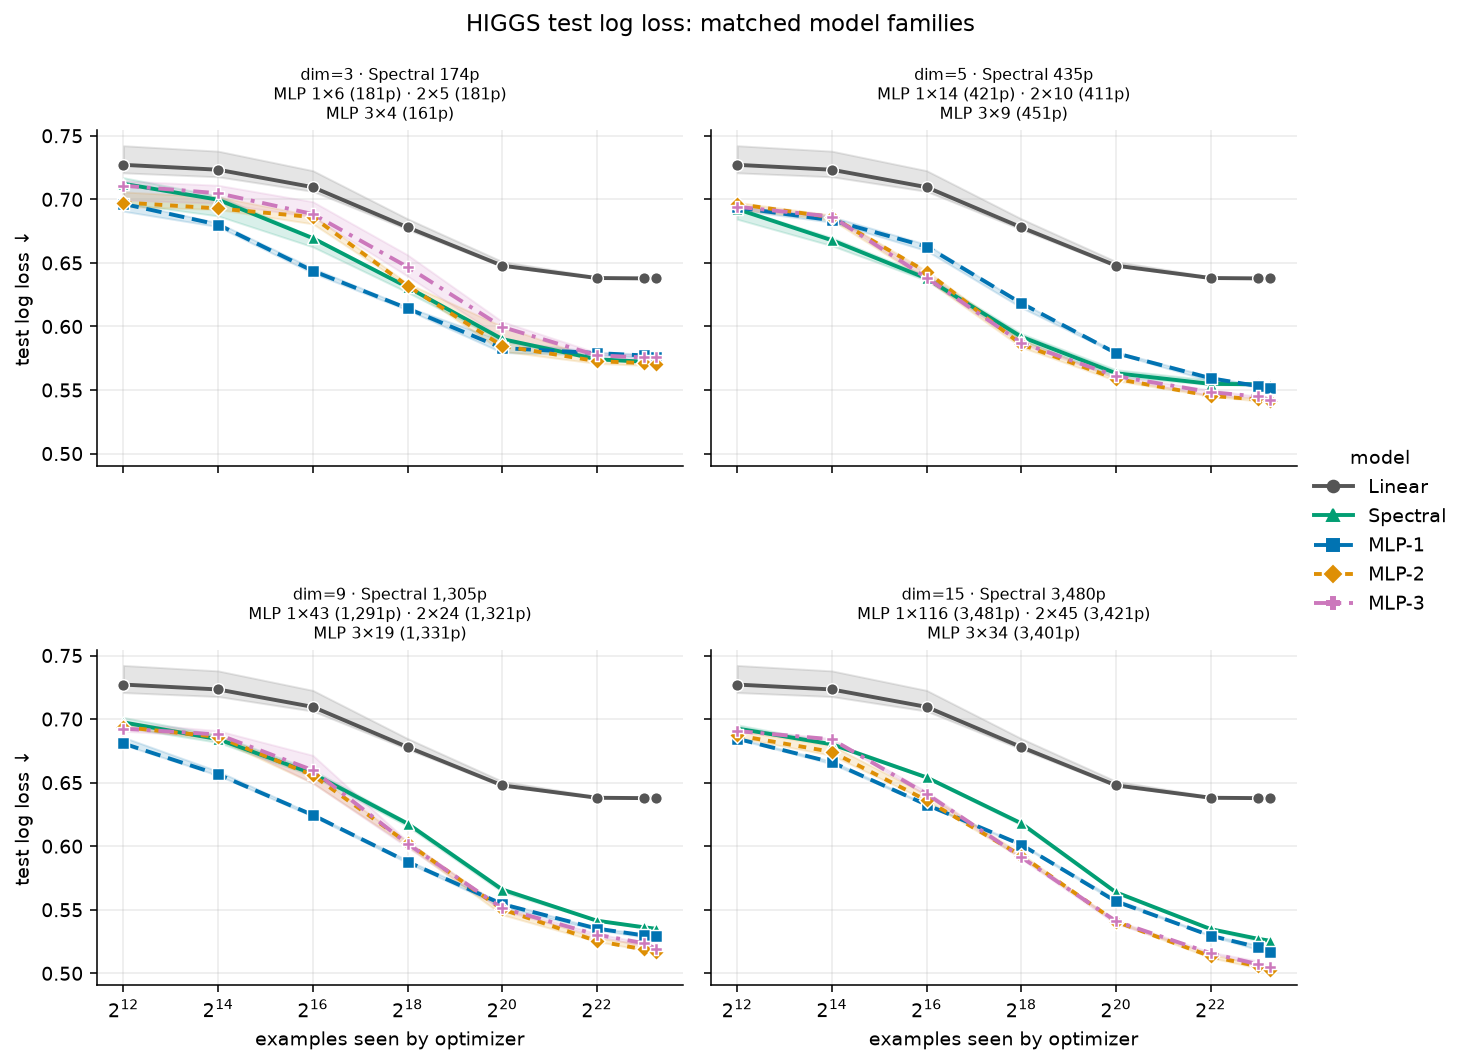

In [7]:
if variant is None:
    plot_higgs_models_by_dimension(selected, metric=metric)
else:
    print(
        "Matched-family facets require the merged result; "
        "set variant=None after appending all family shards."
    )

## Reading the figure

Each facet holds the spectral dimension—and therefore the target parameter budget—fixed. The linear trajectory is repeated as a common reference. The annotation reports the actual spectral parameter count and each MLP's recorded depth, width, and parameter count. Change `metric` in Setup to `"brier"` for the corresponding Brier-score view. Any substantive empirical interpretation should be written only after this notebook has executed against the complete result file.